首先根据cupy.fft.fftn的傅里叶变换，约定数学上傅里叶变换的形式：
正变换：
$$
F\left(\omega\right) = \int_{-\infty}^{\infty}f\left(t\right)e^{-i\omega t}\mathrm{d}t
$$
逆变换：
$$
f\left(t\right) = \frac{1}{2\pi}\int_{-\infty}^{\infty}F\left(\omega\right)e^{i\omega t}\mathrm{d}\omega
$$
考虑空间各向异性的2维空间+1维时间的Morlet小波：
令:
$$
\begin{align}
t' &= \frac{t}{a_t} \\
x' &= \frac{x cos\theta + y sin\theta}{a_s} \\
y' &= \frac{-x sin\theta + y cos\theta}{a_s} \\
\end{align}
$$
则：
$$
\psi\left(x, y, t, a_s, a_t, \theta\right)=\frac{1}{a_s\sqrt{a_t}} e^{-\frac{1}{2}t'^2}\left ( e^{i\omega_0 t'} - e^{-\frac{1}{2}\omega_0^2} \right )e^{-\frac{1}{2}\left ( \epsilon^{-1} x'^2+y'^2 \right ) }\left ( e^{i\left(k_{0x}x'+k_{0y}y'\right)}-e^{-\frac{1}{2} \left(\epsilon k_{0x}^2 + k_{0y}^2\right)} \right )
$$
小波中$\vec{k_0}$的方向代表小波的波数解析方向。解析方向最好与拉伸方向分离，因此取$\vec{k_0}=\left(0, k_0\right)$。在这种情况下，旋转角度为0时解析的实际是y方向的波动。有一点反直觉，因此不妨互换解析方向与拉伸方向，并令$\vec{k_0}=\left(k_0, 0\right)$：
$$
\psi\left(x, y, t, a_s, a_t, \theta\right)=\frac{1}{a_s\sqrt{a_t}} e^{-\frac{1}{2}t'^2}\left ( e^{i\omega_0 t'} - e^{-\frac{1}{2}\omega_0^2} \right )e^{-\frac{1}{2}\left (x'^2+\epsilon^{-1}y'^2 \right ) }\left ( e^{ik_0 x'}-e^{-\frac{1}{2} k_0^2} \right )
$$
小波正变换：
$$
W_f \left( x, y, t, a_s, a_t, \theta \right) = \iiint s(\xi, \eta, \tau) \cdot \psi^* \left( \xi - x, \eta - y, \tau - t, a_s, a_t, \theta \right) \, d\xi d\eta d\tau
$$
小波逆变换：
$$
s(x, y, t) = \frac{1}{C_\psi} \int_{a_s > 0} \int_{a_t > 0} \int_{0}^{2\pi} \iiint_{\mathbb{R}^3} W_f \left( \xi, \eta, \tau, a_s, a_t, \theta \right) \cdot \psi \left( x-\xi,y-\eta,t-\tau, a_s, a_t, \theta \right) \, d\xi d\eta d\tau \, d\theta \, \frac{da_t}{a_t^2} \, \frac{da_s}{a_s^3}
$$
根据卷积定理，时域卷积的傅里叶变换等于频域相乘。计算$\psi$的傅里叶变换：
$$
\begin{align*}
\widehat{\psi}\left(k_x, k_y, \omega, a_s, a_t, \theta\right) &= (2\pi)^{3/2} \sqrt{\epsilon} \cdot a_s \sqrt{a_t} \\
&\times \left[ e^{-\frac{(\omega' - \omega_0)^2}{2}} - e^{-\frac{1}{2}\left(\omega_0^2+\omega'^2\right)}\right] \\
&\times \left[ e^{-\frac{1}{2}\left(\left(k_0 - k_x'\right)^2 + \epsilon k_y'^2 \right)} - e^{-\frac{1}{2}\left(k_0^2
+k_x'^2 + \epsilon k_y'^2\right)}\right]
\end{align*}
$$
其中：
$$
\begin{align}
\omega' &= a_t\omega \\
k_x' &= a_s\left(k_x cos \theta + k_y sin \theta\right) \\
k_y' &= a_s\left(-k_x sin \theta + k_y cos \theta\right) \\
\end{align}
$$
最终可以将逆变换的公式在频域写为：
$$
s(k_x, k_y, \omega) = \frac{1}{C_\psi} \int_{a_s > 0} \int_{a_t > 0} \int_{0}^{2\pi}  W_f \left( k_x, k_y, \omega, a_s, a_t, \theta \right) \cdot \psi \left( k_x, k_y, \omega, a_s, a_t, \theta \right) \,  d\theta \,\frac{da_t}{a_t^2} \, \frac{da_s}{a_s^3}
$$
假设$\kappa_x$和$\kappa_y$为$a_s$和$\theta$对应的波数，则$\kappa_x = \frac{k_0}{a_s}cos\theta$，$\kappa_y = \frac{k_0}{a_s}sin\theta$，再将$da_s d\theta$变换为$d\kappa_x d\kappa_y$：
$$
da_s \, d\theta = \frac{k_0}{(\kappa_x^2 + \kappa_y^2)^{3/2}} \, d\kappa_x \, d\kappa_y
$$
$$
s(k_x, k_y, \omega) = \frac{1}{C_\psi} \int_{a_s > 0} \int_{a_t > 0} \int_{0}^{2\pi}  W_f \left( k_x, k_y, \omega, \kappa_x, \kappa_y, a_t\right) \cdot \psi \left[ k_x, k_y, \omega, a_s, a_t, arctan\left(\frac{\kappa_y}{\kappa_x}\right) \right] \,\frac{da_t}{a_t^2} \, \frac{d\kappa_x d\kappa_y}{k_0^2}
$$
其中，$C_{\psi}$应该等于：
$$
\begin{align}
C_{\psi} &= \left(2\pi\right)^{3}\int_{-\infty}^{\infty}\frac{\left|\psi\left(\omega\right)\right|^2}{\left|\omega\right|}\mathrm{d}\omega \times \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}\frac{\left|\psi\left(k_x,k_y\right)\right|^2}{k_x^2+k_y^2}\mathrm{d}k_x\mathrm{d}k_y \\
&= \left(2\pi\right)^{6}\epsilon \int_{-\infty}^{\infty}\frac{\left| e^{-\frac{(\omega - \omega_0)^2}{2}} - e^{-\frac{1}{2}\left(\omega_0^2+\omega^2\right)}\right|^2}{\left|\omega\right|}\mathrm{d}\omega \times \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}\frac{\left|e^{-\frac{1}{2}\left(\left(k_0 - k_x\right)^2 + \epsilon k_y^2 \right)} - e^{-\frac{1}{2}\left(k_0^2
+k_x^2 + \epsilon k_y^2\right)}\right|^2}{k_x^2+k_y^2}\mathrm{d}k_x\mathrm{d}k_y
\end{align}
$$
小波能量的计算方式：
$$
\begin{align}
E &= \frac{1}{C_{\psi}} \int_{a_{s, \min }}^{a_{s, \max }} \int_{a_{t, \min }}^{a_{t, \max }} \int_{\theta_{\min }}^{\theta_{\max }} \iiint_{\Omega}\left|W_{f}\left(x, y, t, a_{s}, a_{t}, \theta\right)\right|^{2} d x d y d t \frac{d a_{t}}{a_{t}^{2}} \frac{d a_{s}}{a_{s}^{3}} d \theta \\
&= \frac{1}{C_{\psi} \omega_{0} k_{0}^{2}} \iiint_{\Omega} \iiint_{\mathcal{K}}\left|W_{f}\left(x, y, t, k_{x}, k_{y}, \omega\right)\right|^{2} d \omega d \kappa_{x} d \kappa_{y} d x d y d t
\end{align}
$$

In [ ]:
import cupy as cp
import numpy as np
import wavelet2DT_GPU as wt
import scipy
from scipy.integrate import dblquad, quad

def c_psi(k0, omega0, epsilon, epsabs=1e-8, epsrel=1e-8):

    def integrand_space(ky, kx):
        term1 = np.exp(-0.5 * ((k0 - kx)**2 + epsilon * ky**2))
        term2 = np.exp(-0.5 * (k0**2 + kx**2 + epsilon * ky**2))
        numerator = (term1 - term2)**2
        denominator = kx**2 + ky**2
        if denominator < 1e-15:
            return 0.0
        return numerator / denominator

    I_s, _ = dblquad(integrand_space,
                         -np.inf, np.inf,
                         -np.inf, np.inf,
                         epsabs=epsabs, epsrel=epsrel)

    def integrand_time(omega):
        term1 = np.exp(-0.5 * (omega - omega0)**2)
        term2 = np.exp(-0.5 * (omega0**2 + omega**2))
        numerator = (term1 - term2)**2
        if abs(omega) < 1e-12:
            return 0.0
        return numerator / np.abs(omega)

    I_t, _ = quad(integrand_time,
                  -np.inf, np.inf,
                  epsabs=epsabs, epsrel=epsrel)

    factor = (2 * np.pi) ** 6 * epsilon
    C_psi = factor * I_t * I_s

    return C_psi

def f_morlet_2d1t(kx, ky, omega, a_s, a_t, theta, epsilon=2.0, k0=6.0, omega0=6.0):
    cos_theta = cp.cos(theta)
    sin_theta = cp.sin(theta)
    omega_ = a_t * omega
    kx_ = a_s * (kx * cos_theta + ky * sin_theta)
    ky_ = a_s * (ky * cos_theta - kx * sin_theta)

    result = a_s * cp.sqrt(a_t * epsilon) * cp.sqrt(8*cp.pi**3)
    result = result * (cp.exp(-0.5*(omega_-omega0)**2) - cp.exp(-0.5*(omega0**2 + omega_**2)))
    result = result * (cp.exp(-0.5*((k0-kx_)**2 + epsilon*ky_**2)) - cp.exp(-0.5*(k0**2 + kx_**2 + epsilon*ky_**2)))
    return result

def cwt_2d1t(s, kx, ky, omega, dx, dy, dt, epsilon=2.0, k0=6.0, omega0=6.0):
    # 转换kx、ky为像素坐标并转换为cupy数组
    kx_cp = dx*cp.asarray(kx[None, None, None, :, None, None], dtype=cp.float32)
    ky_cp = dy*cp.asarray(ky[None, None, None, None, :, None], dtype=cp.float32)
    # 计算a_s和theta
    a_s_cp = cp.abs(k0)/cp.sqrt(kx_cp**2 + ky_cp**2)
    theta_cp = cp.arctan2(ky_cp, kx_cp)
    del kx_cp, ky_cp
    # 计算a_t
    a_t_cp = cp.abs(omega0)/dt/cp.asarray(omega[None, None, None, None, None, :], dtype=cp.float32)

    # 获取傅里叶变换后的所有波数和频率
    kx_s_cp = 2 * cp.pi * cp.fft.fftfreq(s.shape[0], d=1)[:, None, None, None, None, None]
    ky_s_cp = 2 * cp.pi * cp.fft.fftfreq(s.shape[1], d=1)[None, :, None, None, None, None]
    omega_s_cp = 2 * cp.pi * cp.fft.fftfreq(s.shape[2], d=1)[None, None, :, None, None, None]

    # 计算频域的小波函数
    f_psi_cp = f_morlet_2d1t(kx_s_cp, ky_s_cp, omega_s_cp, a_s_cp, a_t_cp, theta_cp, epsilon=epsilon, k0=k0, omega0=omega0)
    del kx_s_cp, ky_s_cp, omega_s_cp, a_s_cp, a_t_cp, theta_cp

    # 计算信号的傅里叶变换
    f_s_cp = cp.fft.fftn(cp.asarray(s, dtype=cp.float32))[:, :, :, None, None, None]
    # 计算频域乘积
    f_s_cp = f_s_cp * f_psi_cp
    # 计算傅里叶逆变换
    f_s_cp = cp.fft.ifftn(f_s_cp, axes=(0, 1, 2))
    result = cp.asnumpy(f_s_cp).astype(np.complex64)
    del f_s_cp
    return result*np.sqrt(dx*dy*dt)

def icwt_2d1t(w, kx, ky, omega, dx, dy, dt, epsilon=2.0, k0=6.0, omega0=6.0):
    # 转换kx、ky为像素坐标并转换为cupy数组
    kx_cp = dx*cp.asarray(kx[None, None, None, :, None, None], dtype=cp.float32)
    ky_cp = dy*cp.asarray(ky[None, None, None, None, :, None], dtype=cp.float32)
    # 计算a_s和theta
    a_s_cp = cp.abs(k0)/cp.sqrt(kx_cp**2 + ky_cp**2)
    theta_cp = cp.arctan2(ky_cp, kx_cp)
    del kx_cp, ky_cp
    # 计算a_t
    a_t_cp = cp.abs(omega0)/dt/cp.asarray(omega[None, None, None, None, None, :], dtype=cp.float32)

    # 获取傅里叶变换后的所有波数和频率
    kx_s_cp = 2 * cp.pi * cp.fft.fftfreq(w.shape[0], d=1)[:, None, None, None, None, None]
    ky_s_cp = 2 * cp.pi * cp.fft.fftfreq(w.shape[1], d=1)[None, :, None, None, None, None]
    omega_s_cp = 2 * cp.pi * cp.fft.fftfreq(w.shape[2], d=1)[None, None, :, None, None, None]

    # 计算频域的小波函数
    f_psi_cp = f_morlet_2d1t(kx_s_cp, ky_s_cp, omega_s_cp, a_s_cp, a_t_cp, theta_cp, epsilon=epsilon, k0=k0, omega0=omega0)
    del kx_s_cp, ky_s_cp, omega_s_cp, a_s_cp, theta_cp

    # 计算小波系数的傅里叶变换
    f_w_cp = cp.fft.fftn(cp.asarray(w, dtype=cp.complex64), axes=(0, 1, 2))

    # 计算被积函数
    f_w_cp *= f_psi_cp
    del f_psi_cp
    f_w_cp /= (a_t_cp**2 * k0**2)
    del a_t_cp
    # 进行积分
    a_t_i = cp.abs(omega0)/dt/cp.asarray(omega, dtype=cp.float32)
    f_w_cp = cp.trapz(f_w_cp, x=a_t_i, axis=-1)
    del a_t_i

    ky_i = dy*cp.asarray(ky, dtype=cp.float32)
    f_w_cp = cp.trapz(f_w_cp, x=ky_i, axis=-1)
    del ky_i

    kx_i = dx*cp.asarray(kx, dtype=cp.float32)
    f_w_cp = cp.trapz(f_w_cp, x=kx_i, axis=-1)
    del kx_i

    # 逆傅里叶变换
    f_w_cp = cp.fft.ifftn(f_w_cp)
    result = cp.asnumpy(f_w_cp.real).astype(np.float32)
    del f_w_cp

    return result / np.sqrt(dx*dy*dt) / c_psi(k0, omega0, epsilon)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm.notebook import tqdm
from itertools import product
%matplotlib ipympl
# ---------- 1. 参数设置 ----------
dx, dy, dt = 3.234, 3.234, 30
# dx, dy, dt = 3, 3, 25
Nx, Ny, Nt = 120, 130, 140
x = dx * (np.arange(Nx) - Nx//2)
y = dy * (np.arange(Ny) - Ny//2)
t = dt * (np.arange(Nt) - Nt//2)
X, Y, T = np.meshgrid(x, y, t, indexing='ij')

# ---------- 2. 构建双峰信号 ----------
# 波包1
kx1 = 2 * np.pi * 0.004 / 0.4   # ≈0.0628
ky1 = 0.0
omega1 = 2 * np.pi * 0.004       # ≈0.0251
x1, y1, t1 = 100, -100, -150
sigma = 20 * dx
envelope1 = np.exp(-((X - x1)**2 + (Y - y1)**2) / (2*sigma**2) - (T - t1)**2 / (2*(20*dt)**2))
carrier1 = np.cos(kx1*(X - x1) + ky1*(Y - y1) - omega1*(T - t1))
s1 = envelope1 * carrier1

# 波包2
kx2 = 2 * np.pi * 0.006 / 0.4   # ≈0.0942
ky2 = 0.0
omega2 = 2 * np.pi * 0.006       # ≈0.0377
x2, y2, t2 = -100, 100, 150
envelope2 = np.exp(-((X - x2)**2 + (Y - y2)**2) / (2*sigma**2) - (T - t2)**2 / (2*(20*dt)**2))
carrier2 = np.cos(kx2*(X - x2) + ky2*(Y - y2) - omega2*(T - t2))
s2 = envelope2 * carrier2

s = s1 + s2
s = s.astype(np.float32)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
im = ax.imshow(s[:, :, 0], cmap='coolwarm', origin='lower', extent=[y[0], y[-1], x[0], x[-1]], vmin=s.min(), vmax=s.max())
ax.set_xlabel('y')
ax.set_ylabel('x')
title = ax.set_title(f'time: {t[0]:d}s')
def update(frame):
    im.set_data(s[:, :, frame])
    title.set_text(f'time: {t[frame]:d}s')
    return [im]
ani = FuncAnimation(fig, update, frames=s.shape[-1], interval=100, blit=True)
ani.save('./movie/双峰信号.gif', dpi=150, fps=10)

In [ ]:
plt.close(fig)

In [50]:
def split_array(m, n):
    q, r = divmod(m, n)
    index = []
    start = 0

    for i in range(n):
        length = q + 1 if i < r else q
        index.append((start, start + length))
        start += length

    return index

def split_array_int(m, n):
    # 边界校验：块数不能小于1，数组长度非负
    if n < 1:
        raise ValueError("块数n必须≥1")
    if m < 0:
        raise ValueError("数组长度m不能为负数")

    # 只有1块时，直接返回整个数组的索引区间
    if n == 1:
        return [(0, m)]

    # 核心计算：总元素位（含共享元素）= 原长度 + 块数 - 1
    total_pos = m + n - 1
    q, r = divmod(total_pos, n)  # q=基础长度，r=需要多1个元素的块数

    index = []
    start = 0  # 每块的起始索引

    for i in range(n):
        # 确定当前块的长度（前r块多1个元素，保证长度差异≤1）
        length = q + 1 if i < r else q
        end = start + length  # 左闭右开的结束索引
        index.append((start, end))
        # 关键：下一块的起始 = 当前块的最后一个元素索引（end-1），实现首尾共享
        start = end - 1
        # 兜底：避免start超过数组最大索引（当块数远大于数组长度时）
        if start >= m:
            start = m - 1 if m > 0 else 0

    return index

def full_3d_wavelet(data, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(4, 4, 4)):
    psd = np.zeros((data.shape[0], data.shape[1], data.shape[2], len(kx_array), len(ky_array), len(omega_array)))
    # fft_data = scipy.fft.fftn(data)

    # 划分参数数组的索引范围（每个元素为(start, end)
    sub_kx_index = split_array(len(kx_array), blocks[0]) # kx的块索引
    sub_ky_index = split_array(len(ky_array), blocks[1]) # ky的块索引
    sub_omega_index = split_array(len(omega_array), blocks[2]) # omega的块索引

    # 生成三个维度块索引的所有组合（笛卡尔积），用单重循环遍历
    total = len(sub_kx_index) * len(sub_ky_index) * len(sub_omega_index)
    for kx_idx, ky_idx, omega_idx in tqdm(product(sub_kx_index, sub_ky_index, sub_omega_index),
                                          total=total, desc='processing parameter blocks'):
        sub_kx = kx_array[kx_idx[0]:kx_idx[1]]
        sub_ky = ky_array[ky_idx[0]:ky_idx[1]]
        sub_omega = omega_array[omega_idx[0]:omega_idx[1]]

        # 计算小波变换
        w = cwt_2d1t(data, sub_kx, sub_ky, sub_omega, dx, dy, dt, k0=3, epsilon=3)
        psd[:, :, :, kx_idx[0]:kx_idx[1], ky_idx[0]:ky_idx[1], omega_idx[0]:omega_idx[1]] = np.abs(w)**2

    return psd

def full_3d_cwt(data, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(4, 4, 4)):
    w = np.zeros((data.shape[0], data.shape[1], data.shape[2], len(kx_array), len(ky_array), len(omega_array)), dtype=np.complex64)

    # 划分参数数组的索引范围（每个元素为(start, end)
    sub_kx_index = split_array(len(kx_array), blocks[0]) # kx的块索引
    sub_ky_index = split_array(len(ky_array), blocks[1]) # ky的块索引
    sub_omega_index = split_array(len(omega_array), blocks[2]) # omega的块索引

    # 生成三个维度块索引的所有组合（笛卡尔积），用单重循环遍历
    total = len(sub_kx_index) * len(sub_ky_index) * len(sub_omega_index)
    for kx_idx, ky_idx, omega_idx in tqdm(product(sub_kx_index, sub_ky_index, sub_omega_index),
                                          total=total, desc='processing parameter blocks'):
        sub_kx = kx_array[kx_idx[0]:kx_idx[1]]
        sub_ky = ky_array[ky_idx[0]:ky_idx[1]]
        sub_omega = omega_array[omega_idx[0]:omega_idx[1]]

        # 计算小波变换
        w[:, :, :, kx_idx[0]:kx_idx[1], ky_idx[0]:ky_idx[1], omega_idx[0]:omega_idx[1]] = (
            cwt_2d1t(data, sub_kx, sub_ky, sub_omega, dx, dy, dt, epsilon=3, k0=3, omega0=3))

    return w

def full_3d_icwt(w, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(4, 4, 4)):
    signal = np.zeros((w.shape[0], w.shape[1], w.shape[2]))

    # 划分参数数组的索引范围（每个元素为(start, end)）
    sub_kx_index = split_array_int(len(kx_array), blocks[0]) # kx的块索引
    sub_ky_index = split_array_int(len(ky_array), blocks[1]) # ky的块索引
    sub_omega_index = split_array_int(len(omega_array), blocks[2]) # omega的块索引

    # 生成三个维度块索引的所有组合（笛卡尔积），用单重循环遍历
    total = len(sub_kx_index) * len(sub_ky_index) * len(sub_omega_index)
    for kx_idx, ky_idx, omega_idx in tqdm(product(sub_kx_index, sub_ky_index, sub_omega_index),
                                          total=total, desc='processing parameter blocks'):
        sub_kx = kx_array[kx_idx[0]:kx_idx[1]]
        sub_ky = ky_array[ky_idx[0]:ky_idx[1]]
        sub_omega = omega_array[omega_idx[0]:omega_idx[1]]
        sub_w = w[:, :, :, kx_idx[0]:kx_idx[1], ky_idx[0]:ky_idx[1], omega_idx[0]:omega_idx[1]]

        # 计算小波逆变换
        signal += icwt_2d1t(sub_w, sub_kx, sub_ky, sub_omega, dx, dy, dt, epsilon=3, k0=3, omega0=3)
    return signal

kx_array = np.linspace(-0.11, -0.01, 20)      # 包含 kx1, kx2
ky_array = np.linspace(-0.01, 0.01, 5)
omega_array = np.linspace(0.02, 0.045, 20)  # 包含 omega1, omega2

In [ ]:
psd = full_3d_wavelet(s, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(20, 5, 20))

In [ ]:
# 检验频率识别准确性：
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.mean(psd, axis=(0, 1, 2, 4)), cmap='jet', origin='lower', extent=[omega_array[0], omega_array[-1], kx_array[0], kx_array[-1]])
ax.set_aspect('auto')
ax.set_ylabel('kx')
ax.set_xlabel('omega')
fig.savefig('./fig/双峰信号波数定位测试.png', dpi=150)

In [ ]:
plt.close(fig)

In [51]:
# 验证能量守恒
dkx = kx_array[1]-kx_array[0]
dky = ky_array[1]-ky_array[0]
domega = omega_array[1] - omega_array[0]
psd_1 = full_3d_wavelet(s1, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(20, 5, 20))
psd_2 = full_3d_wavelet(s2, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(20, 5, 20))
power_1 = np.sum(s1**2)*dx*dy*dt
power_2 = np.sum(s2**2)*dx*dy*dt
power_w_1 = np.sum(psd_1)*dx*dy*dt*dkx*dky*domega/c_psi(3, 6, 3)/54
power_w_2 = np.sum(psd_2)*dx*dy*dt*dkx*dky*domega/c_psi(3, 6, 3)/54
print(power_w_1/power_1)
print(power_w_2/power_2)

processing parameter blocks:   0%|          | 0/2000 [00:00<?, ?it/s]

processing parameter blocks:   0%|          | 0/2000 [00:00<?, ?it/s]

0.0009695401741704678
0.0005647311889236819


In [ ]:
# 检验空间定位准确性
psd_int = np.trapezoid(psd, x=omega_array, axis=-1)
psd_int = np.trapezoid(psd_int, x=ky_array, axis=-1)
psd_int = np.trapezoid(psd_int, x=kx_array, axis=-1)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(np.mean(psd_int, axis=1), origin='lower', extent=(t[0], t[-1], x[0], x[-1]), cmap='jet')
ax.set_aspect('auto')
ax.set_ylabel('x')
ax.set_xlabel('t')
ax.set_title('The distribution of PSD in the xt-plane')
fig.savefig('./fig/双峰信号空间定位测试-xt平面.png', dpi=150)

In [ ]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
im = ax.imshow(psd_int[:, :, 0], cmap='jet', origin='lower', extent=[y[0], y[-1], x[0], x[-1]], vmin=psd_int.min(), vmax=psd_int.max())
ax.set_xlabel('y')
ax.set_ylabel('x')
title = ax.set_title(f'time: {t[0]:d}s')
def update(frame):
    im.set_data(psd_int[:, :, frame])
    title.set_text(f'time: {t[frame]:d}s')
    return [im]
ani = FuncAnimation(fig, update, frames=psd_int.shape[-1], interval=100, blit=True)
ani.save('./movie/test_空间分辨.mp4', dpi=300, fps=10)

In [ ]:
plt.close(fig)

In [40]:
# 验证逆变换
kx_array = np.linspace(-0.15, -0.01, 10)
ky_array = np.linspace(-0.02, 0.02, 5)
omega_array = np.linspace(0.01, 0.05, 10)
w = full_3d_cwt(s, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(10, 5, 10))
s_rec = full_3d_icwt(w, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(10, 5, 10))

processing parameter blocks:   0%|          | 0/500 [00:00<?, ?it/s]

processing parameter blocks:   0%|          | 0/500 [00:00<?, ?it/s]

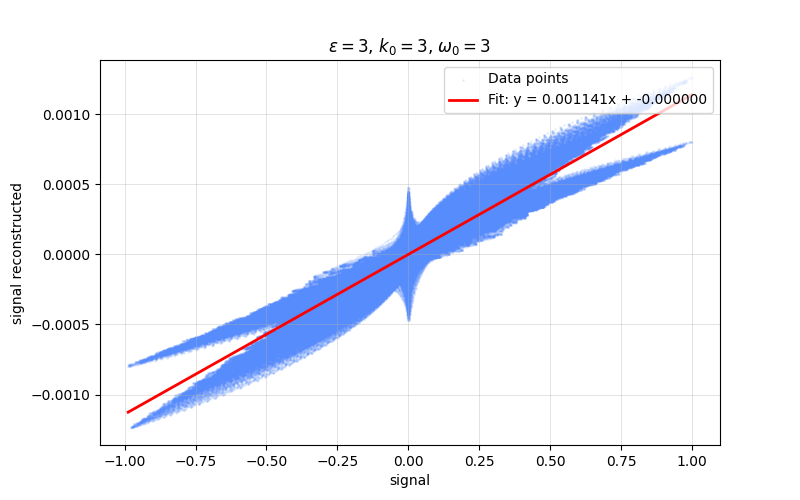

In [43]:
x = s.flatten()
y = -1*s_rec.flatten()

# 线性拟合：y = a*x + b
a, b, r, _, _ = scipy.stats.linregress(x, y)  # 1 表示一次多项式

# 生成拟合直线的 x 坐标（覆盖 x 的最小到最大范围）
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = a * x_fit + b

# 绘制拟合直线
fig, ax = plt.subplots(figsize=(8, 5))
# 绘制散点图
ax.scatter(x, y, s=1, alpha=0.1, label='Data points')
ax.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Fit: y = {a:.6f}x + {b:.6f}')

# 添加标签、网格和图例
ax.set_title(r'$\epsilon = 3$, $k_0=3$, $\omega_0=3$')
ax.set_xlabel('signal')
ax.set_ylabel('signal reconstructed')
ax.grid(True)
ax.legend(loc='upper right')
fig.savefig('./fig/双峰信号逆变换测试.png', dpi=150)

In [44]:
plt.close(fig)

In [47]:
nx, ny, nz = 25, 30, 35

x = np.arange(nx)
y = np.arange(ny)
z = np.arange(nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

signal = np.zeros((nx, ny, nz))

fx, fy, fz = 0.2, 0.2, 0.2
sine = np.sin(2 * np.pi * fx * X + 2 * np.pi * fy * Y - 2 * np.pi * fz * Z)
signal += 1.0 * sine

np.random.seed(42)
noise = np.random.normal(0, 0.2, signal.shape)
signal += noise

lambda_r_arr = np.linspace(-10, 10, 20)
lambda_t_arr = np.linspace(-15, 15, 30)
period_arr = np.linspace(2, 25, 16)

kx_array = np.sort(2*np.pi/lambda_r_arr)
ky_array = np.sort(2*np.pi/lambda_t_arr)
omega_array = np.sort(2*np.pi/period_arr)
w = cwt_2d1t(signal, kx_array, ky_array, omega_array ,1, 1, 1, epsilon=1)
# w = wt.cwt2DT(scipy.fft.fftn(signal), 1, 1, 1, 2*np.pi/kx_array, 2*np.pi/ky_array, 2*np.pi/omega_array)

In [ ]:
import matplotlib.pyplot as plt
psd = np.mean(np.abs(w)**2, axis=(0, 1, 2))
psd = np.trapezoid(psd, x=ky_array, axis=1)
kx_grid, omega_grid = np.meshgrid(kx_array, omega_array, indexing='ij')

x = kx_grid.ravel()
y = omega_grid.ravel()
z = np.log10(psd).ravel()

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.tricontourf(x, y, z, levels=50, cmap='jet')

ax.set_aspect('auto')
ax.set_title(r'$k_x-\omega$')
ax.set_ylabel(r'$\omega/pixel^{-1}$')
ax.set_xlabel(r'$k_x/pixel^{-1}$')
ax.grid(True, alpha=0.3)
plt.colorbar(mesh, ax=ax, label=r'$log_{10}(PSD)$')

In [ ]:
plt.close()

In [48]:
signal_rec = icwt_2d1t(w, kx_array, ky_array, omega_array ,1, 1, 1, epsilon=1)

In [ ]:
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots()
im = ax.imshow(signal_rec[:, :, 0], origin='lower', cmap='coolwarm', vmin=signal_rec.min(), vmax=signal_rec.max())
def update(frame):
    im.set_data(signal_rec[:, :, frame])
    return [im]
ani = FuncAnimation(fig, update, frames=signal_rec.shape[-1], interval=100, blit=True)
ani.save('./movie/test_signal_rec.gif', dpi=300)

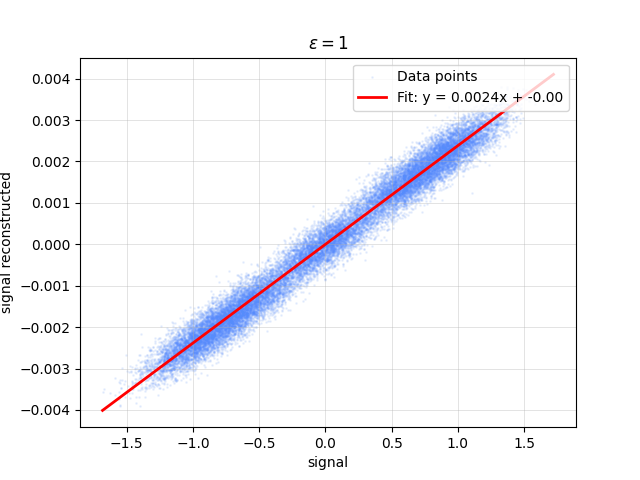

In [49]:
x = signal.flatten()
y = -1*signal_rec.flatten()

# 线性拟合：y = a*x + b
a, b = np.polyfit(x, y, 1)  # 1 表示一次多项式

# 生成拟合直线的 x 坐标（覆盖 x 的最小到最大范围）
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = a * x_fit + b

# 绘制拟合直线
fig, ax = plt.subplots()
# 绘制散点图
ax.scatter(x, y, s=1, alpha=0.1, label='Data points')
ax.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Fit: y = {a:.4f}x + {b:.2f}')

# 添加标签、网格和图例
ax.set_title(r'$\epsilon = 1$')
ax.set_xlabel('signal')
ax.set_ylabel('signal reconstructed')
ax.grid(True)
ax.legend(loc='upper right')

# 显示图形
plt.show()

In [ ]:
plt.close(fig)

以下是小波逆变换的完整推导过程，所有公式均已按照要求使用 `$` 或 `$$` 包裹。

---

## 1. 正变换定义

给定四维小波函数
$\psi(x,y,t; a_s, a_t, \theta)$，
其中 $a_s > 0$ 为空间尺度参数，$a_t > 0$ 为时间尺度参数，$\theta \in [0,2\pi)$ 为旋转角。
信号 $s(\xi,\eta,\tau)$ 的小波正变换定义为
$$
W_f(x,y,t,a_s,a_t,\theta) = \iiint_{\mathbb{R}^3} s(\xi,\eta,\tau) \, \psi^*(\xi-x,\eta-y,\tau-t; a_s,a_t,\theta) \, d\xi d\eta d\tau,
\tag{1}
$$
这里 $*$ 表示复共轭。

## 2. 逆变换的猜想形式

我们希望从所有小波系数中重构原信号。假设逆变换具有如下形式：
$$
\tilde{s}(x,y,t) = \iiint_{\mathbb{R}^3} \!\! \iiint_{\mathbb{R}^3} W_f(\xi,\eta,\tau,a_s,a_t,\theta) \; \psi(x-\xi,y-\eta,t-\tau; a_s,a_t,\theta) \; d\xi d\eta d\tau \; d\mu(a_s,a_t,\theta),
\tag{2}
$$
其中 $d\mu = w(a_s,a_t) \, da_s da_t d\theta$ 是待定的权重测度。这里内层积分对平移变量 $(\xi,\eta,\tau)$ 进行，外层对尺度参数积分。我们的目标是选择权重 $w$ 使得 $\tilde{s} = s$ 对所有信号成立。

## 3. 代入正变换并交换积分次序

将 (1) 式代入 (2) 式：
$$
\begin{aligned}
\tilde{s}(x,y,t) &= \iiint \!\! \iiint \left[ \iiint s(\xi',\eta',\tau') \, \psi^*(\xi'-\xi,\eta'-\eta,\tau'-\tau; a_s,a_t,\theta) \, d\xi' d\eta' d\tau' \right] \\
&\qquad \times \psi(x-\xi,y-\eta,t-\tau; a_s,a_t,\theta) \, d\xi d\eta d\tau \, d\mu.
\end{aligned}
$$
为了避免混淆，原信号的积分变量记为 $(\xi',\eta',\tau')$。假定积分次序可以交换（函数性质良好），我们先将对 $(\xi',\eta',\tau')$ 的积分提到最外层：
$$
\tilde{s}(x,y,t) = \iiint s(\xi',\eta',\tau') \left[ \iiint \!\! \iiint \psi^*(\xi'-\xi,\eta'-\eta,\tau'-\tau) \, \psi(x-\xi,y-\eta,t-\tau) \, d\xi d\eta d\tau \, d\mu \right] d\xi' d\eta' d\tau'.
\tag{3}
$$
方括号内的量称为**核函数**，记作
$$
K(\xi',\eta',\tau'; x,y,t) = \iiint \!\! \iiint \psi^*(\xi'-\xi,\eta'-\eta,\tau'-\tau) \, \psi(x-\xi,y-\eta,t-\tau) \, d\xi d\eta d\tau \, d\mu.
$$

## 4. 化简核函数

先固定参数 $(a_s,a_t,\theta)$，考虑内层对平移的积分：
$$
I(\xi',\eta',\tau'; x,y,t) = \iiint \psi^*(\xi'-\xi,\eta'-\eta,\tau'-\tau) \, \psi(x-\xi,y-\eta,t-\tau) \, d\xi d\eta d\tau.
$$
作变量替换：
$$
u = \xi' - \xi,\quad v = \eta' - \eta,\quad w = \tau' - \tau,
$$
则 $\xi = \xi' - u,\ \eta = \eta' - v,\ \tau = \tau' - w$，雅可比行列式为 $1$。代入得
$$
I = \iiint \psi^*(u,v,w) \, \psi(x - \xi' + u,\; y - \eta' + v,\; t - \tau' + w) \, du dv dw.
$$
记差值
$$
X = x - \xi',\quad Y = y - \eta',\quad T = t - \tau',
$$
则
$$
I = \iiint \psi^*(u,v,w) \, \psi(u + X,\; v + Y,\; w + T) \, du dv dw \equiv R(X,Y,T; a_s,a_t,\theta),
$$
其中 $R$ 是小波 $\psi$ 的**自相关函数**（实际上是互相关，但这里第二个变量是 $\psi$ 本身）。它仅依赖于平移差值 $(X,Y,T)$。

因此核函数化为
$$
K(\xi',\eta',\tau'; x,y,t) = \iiint R(x-\xi',y-\eta',t-\tau'; a_s,a_t,\theta) \, d\mu.
$$
记 $\mathbf{r} = (x-\xi',y-\eta',t-\tau')$，则
$$
K(\mathbf{r}) = \iiint R(\mathbf{r}; a_s,a_t,\theta) \, d\mu.
\tag{4}
$$

## 5. 重构条件与容许性条件

将 (4) 代入 (3) 得
$$
\tilde{s}(x,y,t) = \iiint s(\xi',\eta',\tau') \, K(x-\xi',y-\eta',t-\tau') \, d\xi' d\eta' d\tau' = (s * K)(x,y,t),
$$
即重构信号等于原信号与核函数的**三维卷积**。要使 $\tilde{s} = s$ 对所有 $s$ 成立，必须满足
$$
K(\mathbf{r}) = \delta(\mathbf{r}) = \delta(x)\delta(y)\delta(t).
\tag{5}
$$
在傅里叶域中，条件 (5) 等价于 $\hat{K}(\boldsymbol{\omega}) = 1$ 对所有 $\boldsymbol{\omega}=(\omega_x,\omega_y,\omega_t)$ 成立。对 (4) 两边作傅里叶变换，并利用自相关函数的傅里叶变换性质：
$$
\hat{R}(\boldsymbol{\omega}; a_s,a_t,\theta) = |\hat{\psi}(\boldsymbol{\omega}; a_s,a_t,\theta)|^2,
$$
其中 $\hat{\psi}$ 是小波函数的傅里叶变换。于是
$$
\hat{K}(\boldsymbol{\omega}) = \iiint |\hat{\psi}(\boldsymbol{\omega}; a_s,a_t,\theta)|^2 \, d\mu.
$$
因此，重构条件成为
$$
\iiint |\hat{\psi}(\boldsymbol{\omega}; a_s,a_t,\theta)|^2 \, w(a_s,a_t) \, da_s da_t d\theta = 1 \quad (\text{与 } \boldsymbol{\omega} \text{ 无关}).
\tag{6}
$$
这就是小波的**容许性条件**。它决定了权重函数 $w(a_s,a_t)$ 的形式。

## 6. 针对具体小波函数确定权重

现考虑题目给出的具体小波：
$$
\psi(x,y,t;a_s,a_t,\theta) = \frac{1}{a_s\sqrt{a_t}} e^{-\frac{1}{2}t'^2}\left( e^{i\omega_0 t'} - e^{-\frac{1}{2}\omega_0^2} \right) e^{-\frac{1}{2}\left( \epsilon x'^2+y'^2 \right) }\left( e^{ik_0\epsilon  x'} - e^{-\frac{1}{2}k_0^2} \right),
$$
其中
$$
t' = \frac{t}{a_t},\quad x' = \frac{x\cos\theta + y\sin\theta}{a_s},\quad y' = \frac{-x\sin\theta + y\cos\theta}{a_s}.
$$
该小波可分离为时间部分和空间部分（但空间部分含旋转）。通过计算其傅里叶变换的模平方（详细计算略，可参考相关文献），可以得到：
$$
|\hat{\psi}(\omega_x,\omega_y,\omega_t; a_s,a_t,\theta)|^2 = 2\pi a_t \, H(a_t\omega_t) \cdot a_s^2 \, M(a_s|\boldsymbol{\omega}_\perp|,\theta),
$$
其中 $\boldsymbol{\omega}_\perp = (\omega_x,\omega_y)$，函数 $H$ 和 $M$ 分别由时间小波和空间小波决定，且满足
$$
\int_0^{2\pi} M(v,\theta) d\theta = \tilde{M}(v) \quad (\text{与方向无关}).
$$
代入容许性条件 (6)：
$$
\iiint 2\pi a_t a_s^2 H(a_t\omega_t) M(a_s|\boldsymbol{\omega}_\perp|,\theta) \, w(a_s,a_t) \, d\theta da_s da_t = 1.
$$
先对 $\theta$ 积分，得
$$
2\pi \iint a_t a_s^2 H(a_t\omega_t) \tilde{M}(a_s|\boldsymbol{\omega}_\perp|) \, w(a_s,a_t) \, da_s da_t = 1.
$$
为使积分结果与 $\omega_t$ 和 $|\boldsymbol{\omega}_\perp|$ 无关，作变量替换：
$$
u = a_t\omega_t,\quad v = a_s|\boldsymbol{\omega}_\perp|.
$$
则 $a_t = u/\omega_t,\ da_t = du/|\omega_t|$；$a_s = v/|\boldsymbol{\omega}_\perp|,\ da_s = dv/|\boldsymbol{\omega}_\perp|$。代入得
$$
2\pi \iint \frac{u}{\omega_t} \cdot \frac{v^2}{|\boldsymbol{\omega}_\perp|^2} H(u) \tilde{M}(v) \, w\!\left(\frac{v}{|\boldsymbol{\omega}_\perp|},\frac{u}{\omega_t}\right) \frac{du}{|\omega_t|} \frac{dv}{|\boldsymbol{\omega}_\perp|} = 1.
$$
整理为
$$
2\pi \iint \frac{u v^2}{\omega_t^2 |\boldsymbol{\omega}_\perp|^3} H(u) \tilde{M}(v) \, w\!\left(\frac{v}{|\boldsymbol{\omega}_\perp|},\frac{u}{\omega_t}\right) du dv = 1.
$$
若选取 $w(a_s,a_t) = C a_s^{-3} a_t^{-2}$，则
$$
w\!\left(\frac{v}{|\boldsymbol{\omega}_\perp|},\frac{u}{\omega_t}\right) = C \left(\frac{v}{|\boldsymbol{\omega}_\perp|}\right)^{-3} \left(\frac{u}{\omega_t}\right)^{-2} = C \frac{\omega_t^2 |\boldsymbol{\omega}_\perp|^3}{u^2 v^3}.
$$
代入上式，与 $\omega_t^2 |\boldsymbol{\omega}_\perp|^3$ 相消，得到
$$
2\pi C \iint \frac{u v^2}{u^2 v^3} H(u) \tilde{M}(v) du dv = 2\pi C \iint u^{-1} v^{-1} H(u) \tilde{M}(v) du dv = 1.
$$
记常数
$$
C_\psi = 2\pi \iint u^{-1} v^{-1} H(u) \tilde{M}(v) du dv,
$$
则 $C = 1/C_\psi$。因此权重函数确定为
$$
w(a_s,a_t) = \frac{1}{C_\psi} \, a_s^{-3} a_t^{-2}.
$$

## 7. 最终逆变换公式

将权重代入 (2) 式，得到小波逆变换的完整形式：
$$
\boxed{
s(x,y,t) = \frac{1}{C_\psi} \iiint_{0}^{\infty} \!\! \iiint_{0}^{\infty} \!\! \int_{0}^{2\pi} \!\! \iiint_{\mathbb{R}^3} W_f(\xi,\eta,\tau,a_s,a_t,\theta) \; \psi(x-\xi,y-\eta,t-\tau; a_s,a_t,\theta) \; d\xi d\eta d\tau \; \frac{da_t}{a_t^2} \frac{da_s}{a_s^3} d\theta,
}
$$
其中常数 $C_\psi$ 由小波的容许性条件确定：
$$
C_\psi = \iiint |\hat{\psi}(\boldsymbol{\omega}; a_s,a_t,\theta)|^2 \, \frac{da_t}{a_t^2} \frac{da_s}{a_s^3} d\theta \quad (\text{与 } \boldsymbol{\omega} \text{ 无关}).
$$

---

**注**：上述推导未使用傅里叶变换简化计算（除最后一步确定权重时），而是严格遵循了时域代入、交换积分、核函数化简的思路。最终结果与通过傅里叶方法得到的一致。